In [14]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pydicom as dcm
from pydicom.data import get_testdata_file

import sys, pickle, os, torch, cv2

# replace this path with path to GMIC
sys.path.append("./GMIC/")

from src.data_loading import loading
from src.modeling import gmic as gmic

<bound method Dataset.elements of Dataset.file_meta -------------------------------
(0002, 0000) File Meta Information Group Length  UL: 212
(0002, 0001) File Meta Information Version       OB: b'\x00\x01'
(0002, 0002) Media Storage SOP Class UID         UI: Breast Tomosynthesis Image Storage
(0002, 0003) Media Storage SOP Instance UID      UI: 1.2.826.0.1.3680043.8.498.72855655035226826807310008767733798435
(0002, 0010) Transfer Syntax UID                 UI: JPEG 2000 Image Compression (Lossless Only)
(0002, 0012) Implementation Class UID            UI: 1.3.6.1.4.1.22213.1.143
(0002, 0013) Implementation Version Name         SH: '0.5'
(0002, 0016) Source Application Entity Title     AE: 'POSDA'
-------------------------------------------------
(0008, 0005) Specific Character Set              CS: 'ISO_IR 100'
(0008, 0008) Image Type                          CS: ['DERIVED', 'PRIMARY', 'TOMOSYNTHESIS', 'NONE']
(0008, 0016) SOP Class UID                       UI: Breast Tomosynthesis Ima

/opt/homebrew/Caskroom/miniforge/base/envs/learning/lib/python3.11/site-packages/pydicom/pixel_data_handlers/pillow_handler.py:238: UserWarning: The (0028,0101) 'Bits Stored' value (10-bit) doesn't match the JPEG 2000 data (16-bit). It's recommended that you change the 'Bits Stored' value
  warnings.warn(


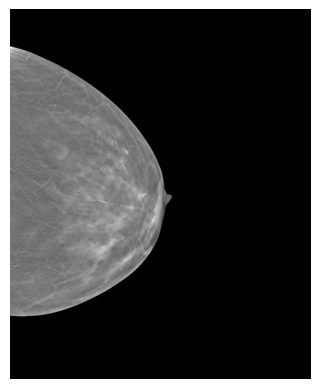

In [31]:
# path = get_testdata_file("CT_small.dcm") # download sample dataset
path = "Data/BSC-DBT/DBT-P00538/01-01-2000-DBT-S01986-MAMMO screening digital bilateral-71001/14154.000000-69041/1-1.dcm"

ds = dcm.dcmread(path, force=True) # dicom dataset
print(ds.elements)

arr = ds.pixel_array # numpy.ndarray
pngImage = arr[2]

plt.imshow(pngImage, cmap="gray")
plt.axis("off")
# plt.savefig("output.png")

print(type(ds))
print(type(pngImage))
print(np.min(pngImage))
print(np.max(pngImage))
print(pngImage.shape)

In [3]:
sample = Image.open("output.png")
sample = np.array(sample)
print(type(sample))
print(sample.shape)

<class 'numpy.ndarray'>
(2457, 1996)


<class 'numpy.ndarray'>
0.0
986.0
(2457, 1996)


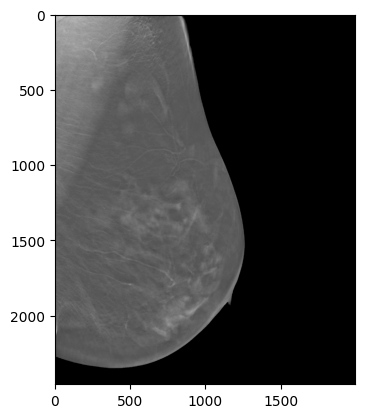

In [63]:
path = "output.png"
view = "L-CC"
horizontal_flip = "YES"

loaded_image = loading.load_image(
                    image_path=path,
                    view=view, horizontal_flip=horizontal_flip)

print(type(loaded_image))
print(np.min(loaded_image))
print(np.max(loaded_image))
print(loaded_image.shape)

plt.imshow(loaded_image, cmap="gray")

In [64]:
best_center = (800, 400)

loaded_image = loading.process_image(loaded_image, view, best_center)

(2944, 1920)
4.1398


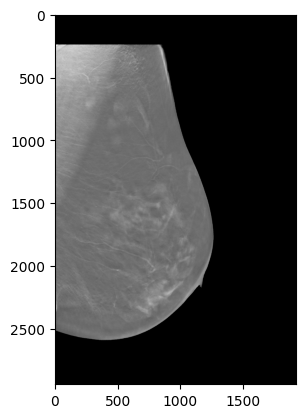

In [65]:
print(loaded_image.shape)
print(np.max(loaded_image))
plt.imshow(loaded_image, cmap="Greys_r")
# plt.axis("off")
plt.savefig("mammoOriginal.png")
plt.show()

In [66]:
parameters = {
        "device_type":"cpu",
        "cam_size": (46, 30),
        "K": 6,
        "crop_shape": (256, 256),
        "percent_t": 0.02, 
        "post_processing_dim": 256,
        "num_classes": 2
    }

model = gmic.GMIC(parameters)

In [67]:
model.load_state_dict(torch.load("GMIC/models/sample_model_1.p", map_location="cpu"), strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['shared_rep_filter.weight'])

In [68]:
tensor_batch = torch.Tensor(np.expand_dims(np.expand_dims(loaded_image, 0), 0).copy())
output = model(tensor_batch)
pred_numpy = output.data.cpu().numpy()
begnin_pred = pred_numpy[0,0]
malignant_pred = pred_numpy[0, 1]

In [69]:
print("begnin prediction = {}".format(begnin_pred))
print("malignant prediction = {}".format(malignant_pred))

begnin prediction = 0.08261479437351227
malignant prediction = 0.02686954475939274


/var/folders/d7/q72cpd5d6bv6knpx85s28lq80000gn/T/ipykernel_4883/3587859275.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  alpha_red = plt.cm.get_cmap('Reds')


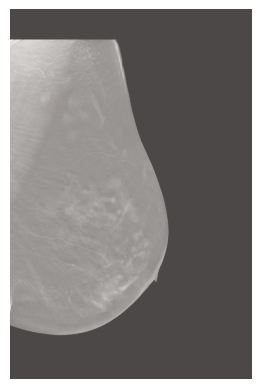

In [70]:
saliency_maps = model.saliency_map.data.cpu().numpy()
malignant_saliency_map = saliency_maps[0,1,:,:]
alphas = np.abs(np.linspace(0, 0.95, 259))
alpha_red = plt.cm.get_cmap('Reds')
plt.figure()
plt.imshow(loaded_image, cmap="Greys_r")
plt.imshow(cv2.resize(malignant_saliency_map, (1920, 2944)), alpha=0.3, cmap=alpha_red, clim=[0.0, 1.0])
plt.axis("off")
plt.savefig("mammoResult.png")
plt.show()

In [30]:
with open("Data/BSC-DBT/exam_list.pkl", "rb") as f:
    exam_list = pickle.load(f)

print(exam_list)

[{'horizontal_flip': 'NO', 'L-CC': ['3_L-CC'], 'L-MLO': ['3_L-MLO'], 'cancer_label': {'benign': 0, 'right_benign': 0, 'malignant': 0, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 0}}, {'horizontal_flip': 'NO', 'R-CC': ['4_R-CC'], 'L-CC': ['4_L-CC'], 'R-MLO': ['4_R-MLO'], 'L-MLO': ['4_L-MLO'], 'cancer_label': {'benign': 0, 'right_benign': 0, 'malignant': 0, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 0}}]


In [22]:
with open("GMIC/sample_output/data.pkl", "rb") as f:
    exam_list = pickle.load(f)

print(exam_list)

[{'horizontal_flip': 'NO', 'L-CC': ['0_L-CC'], 'L-MLO': ['0_L-MLO'], 'R-MLO': ['0_R-MLO'], 'R-CC': ['0_R-CC'], 'cancer_label': {'benign': 1, 'right_benign': 1, 'malignant': 0, 'left_benign': 0, 'unknown': 0, 'right_malignant': 0, 'left_malignant': 0}, 'L-CC_benign_seg': ['0_L-CC_benign'], 'L-CC_malignant_seg': ['0_L-CC_malignant'], 'L-MLO_benign_seg': ['0_L-MLO_benign'], 'L-MLO_malignant_seg': ['0_L-MLO_malignant'], 'R-MLO_benign_seg': ['0_R-MLO_benign'], 'R-MLO_malignant_seg': ['0_R-MLO_malignant'], 'R-CC_benign_seg': ['0_R-CC_benign'], 'R-CC_malignant_seg': ['0_R-CC_malignant'], 'window_location': {'L-CC': [(0, 2023, 0, 801)], 'R-CC': [(0, 2144, 0, 801)], 'L-MLO': [(0, 2730, 0, 981)], 'R-MLO': [(0, 2650, 0, 1006)]}, 'rightmost_points': {'L-CC': [((948, 957), 750)], 'R-CC': [((1232, 1249), 751)], 'L-MLO': [((1733, 1749), 930)], 'R-MLO': [((1571, 1648), 956)]}, 'bottommost_points': {'L-CC': [(1972, (100, 100))], 'R-CC': [(2093, (101, 101))], 'L-MLO': [(2679, (100, 101))], 'R-MLO': [(25

In [ ]:
with open("GMIC/sample_data/", "rb") as f:
    exam_list = pickle.load(f)

print(exam_list)